# 1. Handle Missing Data

In [45]:
import pandas as pd

In [46]:
data = {
    'Name': ['Pawan', 'Kapil', 'Lalit', 'Ishan', 'Om'],
    'Age': [25, None, 44, 23, None],
    'Salary': [50000, 60000, 70000, None, None]
}
df=pd.DataFrame(data)
print("Original Dataframe")
print(df)

Original Dataframe
    Name   Age   Salary
0  Pawan  25.0  50000.0
1  Kapil   NaN  60000.0
2  Lalit  44.0  70000.0
3  Ishan  23.0      NaN
4     Om   NaN      NaN


In [47]:
#isnull().sum()
print(df.isnull().sum())

Name      0
Age       2
Salary    2
dtype: int64


In [48]:
# dropna()
df_drop = df.dropna()
print(df_drop)

    Name   Age   Salary
0  Pawan  25.0  50000.0
2  Lalit  44.0  70000.0


In [49]:
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Salary'].fillna(df['Salary'].mean(), inplace=True)
print(df)

    Name        Age   Salary
0  Pawan  25.000000  50000.0
1  Kapil  30.666667  60000.0
2  Lalit  44.000000  70000.0
3  Ishan  23.000000  60000.0
4     Om  30.666667  60000.0


C:\Users\Vicky\AppData\Local\Temp\ipykernel_8136\2804555975.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
C:\Users\Vicky\AppData\Local\Temp\ipykernel_8136\2804555975.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [50]:
'''Note:-
1. don't directly drop data. try to fill the data first
2. if you are deailing wiht numerical data so fill with mean or median
3. and if you are deailing with categorial data so fill with mode or placeholder like unknonw or something

always check how much percentage missing data is 
print(df.isnull().mean()*100) 
'''

"Note:-\n1. don't directly drop data. try to fill the data first\n2. if you are deailing wiht numerical data so fill with mean or median\n3. and if you are deailing with categorial data so fill with mode or placeholder like unknonw or something\n\nalways check how much percentage missing data is \nprint(df.isnull().mean()*100) \n"

# 2. Encode Categorical Values

In [51]:
# 1. label Encoding
'''
Gender     Encoded
Male        0
Female      1
'''

'\nGender     Encoded\nMale        0\nFemale      1\n'

In [52]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

In [53]:
df = pd.read_csv("d1.csv")
df_label = df.copy()
print(df_label)

     Name  Gender       City  Passed
0     Aman    Male      Delhi    Yes
1    Priya  Female     Mumbai    Yes
2    Rahul    Male  Bangalore     No
3   Anjali  Female     Mumbai    Yes
4     Ravi    Male      Delhi    Yes
5    Meera  Female    Chennai     No
6    Arjun    Male  Bangalore    Yes
7     Neha  Female      Delhi    Yes
8    Imran    Male    Chennai     No
9    Sneha  Female     Mumbai    Yes
10     Raj    Male    Chennai    Yes
11  Diovya  Female     Mumbai     No
12   Kabir    Male    Chennai    Yes
13  Simran  Female      Delhi    Yes
14   Karan    Male     Mumbai     No
15   Pooja  Female  Bangalore    Yes
16  Rakesh    Male      Delhi    Yes
17    Isha  Female    Chennai     No
18   Rohit    Male      Delhi    Yes
19   Deepa  Female     Mumbai    Yes


In [54]:
le = LabelEncode
df_label['Gender_Encoded'] = le.fit_transform(df_label['Gender '])
df_label['Passed_Encoded'] = le.fit_transform(df_label['Passed'])# here fit stand for learn from values and than transform it using transfrorm


In [55]:
for col in df_label.columns:
    print(f"'{col}'")


'Name '
'Gender '
'City '
'Passed'
'Gender_Encoded'
'Passed_Encoded'


In [56]:
print('\nLabel Encoded Data')
print(df_label[['Name ', 'Gender ', 'Gender_Encoded', 'Passed', 'Passed_Encoded']])


Label Encoded Data
     Name  Gender   Gender_Encoded Passed  Passed_Encoded
0     Aman    Male               1    Yes               1
1    Priya  Female               0    Yes               1
2    Rahul    Male               1     No               0
3   Anjali  Female               0    Yes               1
4     Ravi    Male               1    Yes               1
5    Meera  Female               0     No               0
6    Arjun    Male               1    Yes               1
7     Neha  Female               0    Yes               1
8    Imran    Male               1     No               0
9    Sneha  Female               0    Yes               1
10     Raj    Male               1    Yes               1
11  Diovya  Female               0     No               0
12   Kabir    Male               1    Yes               1
13  Simran  Female               0    Yes               1
14   Karan    Male               1     No               0
15   Pooja  Female               0    Yes           

In [60]:
# 2. One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['City ']) #text column to convert small binaary number
print('\nOne-Hot Encoded Data(City)')
df_encoded


One-Hot Encoded Data(City)


,Name,Gender,Passed,City _Bangalore,City _Chennai,City _Delhi,City _Mumbai
0,Aman,Male,Yes,False,False,True,False
1,Priya,Female,Yes,False,False,False,True
2,Rahul,Male,No,True,False,False,False
3,Anjali,Female,Yes,False,False,False,True
4,Ravi,Male,Yes,False,False,True,False
5,Meera,Female,No,False,True,False,False
6,Arjun,Male,Yes,True,False,False,False
7,Neha,Female,Yes,False,False,True,False
8,Imran,Male,No,False,True,False,False
9,Sneha,Female,Yes,False,False,False,True


In [63]:
for col in df_encoded.columns:
    print(f"'{col}'")

'Name '
'Gender '
'Passed'
'City _Bangalore'
'City _Chennai'
'City _Delhi'
'City _Mumbai'


In [65]:
cols_to_convert = ['City _Bangalore', 'City _Chennai', 'City _Delhi', 'City _Mumbai']
df_encoded[cols_to_convert] = df_encoded[cols_to_convert].astype(int)#convert into nummerical type
df_encoded

,Name,Gender,Passed,City _Bangalore,City _Chennai,City _Delhi,City _Mumbai
0,Aman,Male,Yes,0,0,1,0
1,Priya,Female,Yes,0,0,0,1
2,Rahul,Male,No,1,0,0,0
3,Anjali,Female,Yes,0,0,0,1
4,Ravi,Male,Yes,0,0,1,0
5,Meera,Female,No,0,1,0,0
6,Arjun,Male,Yes,1,0,0,0
7,Neha,Female,Yes,0,0,1,0
8,Imran,Male,No,0,1,0,0
9,Sneha,Female,Yes,0,0,0,1


# 3. Feature Scaling

In [68]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform()

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform()


TypeError: TransformerMixin.fit_transform() missing 1 required positional argument: 'X'

In [70]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

# StandardScaler <br> <br>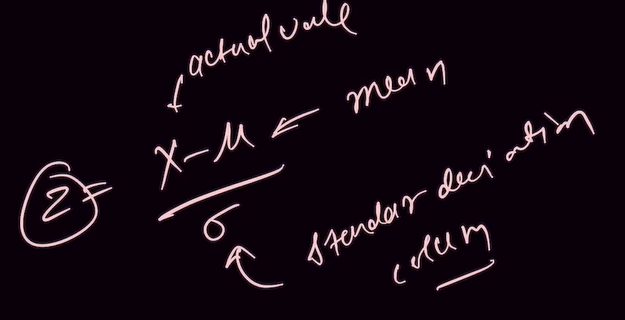

# MinMaxScaler <br><br>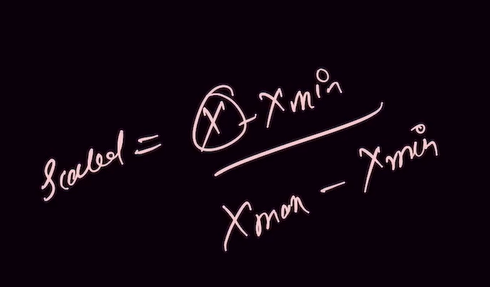

In [74]:
data = {
    'StudyHours':[1,2,3,4,5],
    'TestScore':[40,50,60,70,80]
}
df=pd.DataFrame(data)

#standardscaler
standard_scaler = StandardScaler()
standard_scaled = standard_scaler.fit_transform(df)

print("Standard Scaled Output;")
print(pd.DataFrame(standard_scaled, columns=['StudyHours', 'TestScore']))

#minmaxscaler
minmax_scaler = MinMaxScaler()
minmax_scaled = minmax_scaler.fit_transform(df)

print("\n\nMinMax Scaled Output;")
print(pd.DataFrame(minmax_scaled, columns=['StudyHours', 'TestScore']))

Standard Scaled Output;
   StudyHours  TestScore
0   -1.414214  -1.414214
1   -0.707107  -0.707107
2    0.000000   0.000000
3    0.707107   0.707107
4    1.414214   1.414214


MinMax Scaled Output;
   StudyHours  TestScore
0        0.00       0.00
1        0.25       0.25
2        0.50       0.50
3        0.75       0.75
4        1.00       1.00


# 4. Split Data

In [83]:
X = df[['StudyHours']]
y = df[['TestScore']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
print("\nTraining Data")
print(X_train)

print("\nTesting Data")
print(X_test)

print("\nTraining Data")
print(y_train)

print("\nTesting Data")
print(y_test)


Training Data
   StudyHours
4           5
1           2
3           4
0           1

Testing Data
   StudyHours
2           3

Training Data
   TestScore
4         80
1         50
3         70
0         40

Testing Data
   TestScore
2         60
